In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

In [2]:
train_path = "/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TRAIN"
test_path  = "/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TEST"

In [3]:
def count_images(data_path):
    class_counts = {}
    
    for class_name in os.listdir(data_path):
        class_dir = os.path.join(data_path, class_name)
        
        if os.path.isdir(class_dir):
            num_images = len([
                file for file in os.listdir(class_dir) 
                if file.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_counts[class_name] = num_images
    
    return class_counts

In [4]:
train_counts = count_images(train_path)
test_counts = count_images(test_path)

print("Train Data Distribution:")
print(train_counts)

print("\nTest Data Distribution:")
print(test_counts)

Train Data Distribution:
{'R': 9999, 'O': 12565}

Test Data Distribution:
{'R': 1112, 'O': 1401}


In [5]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

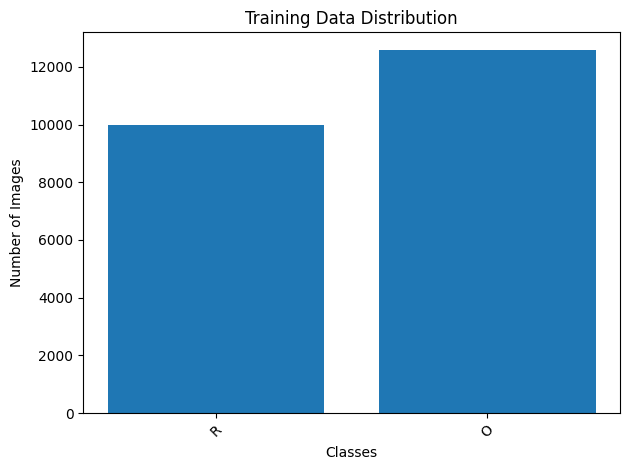

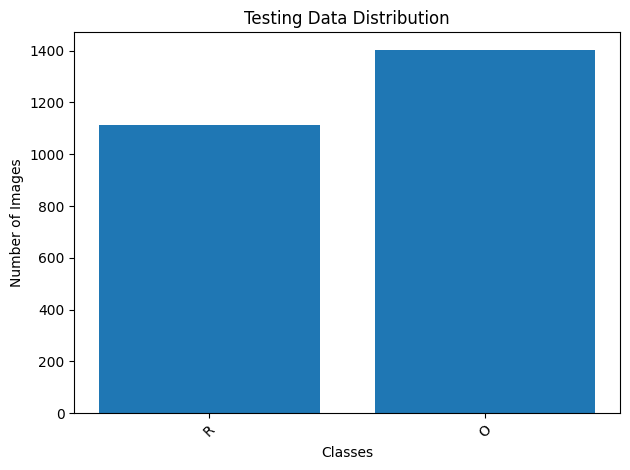

In [6]:
def plot_distribution(counts, title):
    classes = list(counts.keys())
    values = list(counts.values())
    
    plt.figure()
    plt.bar(classes, values)
    plt.xticks(rotation=45)
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_distribution(train_counts, "Training Data Distribution")
plot_distribution(test_counts, "Testing Data Distribution")

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-04-19 09:24:37.883623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776590678.044402      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776590678.090335      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776590678.455935      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776590678.455967      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776590678.455969      55 computation_placer.cc:177] computation placer alr

In [10]:
train_dir = "/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TRAIN"
test_dir  = "/kaggle/input/datasets/techsash/waste-classification-data/DATASET/TEST"

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 18052 images belonging to 2 classes.
Found 4512 images belonging to 2 classes.
Found 2513 images belonging to 2 classes.


In [12]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['O', 'R']


## Baseline CNN

In [13]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
baseline_model = build_baseline_cnn()

history_baseline = baseline_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776590767.412647      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776590767.418544      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can i

Epoch 1/10


I0000 00:00:1776590771.537626     182 service.cc:152] XLA service 0x7fb9980067c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776590771.537662     182 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776590771.537666     182 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776590771.904916     182 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-19 09:26:14.294896: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 09:26:14.442598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/565 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.4609 - loss: 2.7022  

I0000 00:00:1776590777.009763     182 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


169/565 ━━━━━━━━━━━━━━━━━━━━ 3:15 494ms/step - accuracy: 0.7292 - loss: 0.8119

2026-04-19 09:27:40.903658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 09:27:41.046090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


565/565 ━━━━━━━━━━━━━━━━━━━━ 356s 617ms/step - accuracy: 0.7775 - loss: 0.5833 - val_accuracy: 0.7828 - val_loss: 0.4431
Epoch 2/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 234s 414ms/step - accuracy: 0.8301 - loss: 0.3947 - val_accuracy: 0.7786 - val_loss: 0.4655
Epoch 3/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 236s 418ms/step - accuracy: 0.8456 - loss: 0.3642 - val_accuracy: 0.8138 - val_loss: 0.4041
Epoch 4/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 239s 423ms/step - accuracy: 0.8551 - loss: 0.3445 - val_accuracy: 0.8411 - val_loss: 0.4048
Epoch 5/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 237s 419ms/step - accuracy: 0.8643 - loss: 0.3293 - val_accuracy: 0.8347 - val_loss: 0.3727
Epoch 6/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 241s 426ms/step - accuracy: 0.8723 - loss: 0.3107 - val_accuracy: 0.8324 - val_loss: 0.3780
Epoch 7/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 236s 418ms/step - accuracy: 0.8783 - loss: 0.3032 - val_accuracy: 0.8506 - val_loss: 0.3857
Epoch 8/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 235s 416ms/step - accuracy: 0.8743 - loss: 0.30

## VGG 19

In [15]:
def build_vgg19():
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(len(class_names), activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [16]:
vgg_model = build_vgg19()

history_vgg = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 282s 466ms/step - accuracy: 0.7819 - loss: 0.7342 - val_accuracy: 0.8628 - val_loss: 0.3593
Epoch 2/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 257s 455ms/step - accuracy: 0.8551 - loss: 0.3497 - val_accuracy: 0.8608 - val_loss: 0.3653
Epoch 3/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 272s 480ms/step - accuracy: 0.8610 - loss: 0.3385 - val_accuracy: 0.8728 - val_loss: 0.3353
Epoch 4/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 260s 459ms/step - accuracy: 0.8662 - loss: 0.3215 - val_accuracy: 0.8562 - val_loss: 0.3833
Epoch 5/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 255s 451ms/step - accuracy: 0.8711 - loss: 0.3081 - val_accuracy: 0.8672 - val_loss: 0.3616
Epoch 6/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 259s 458ms/step - accuracy: 0.8713 - loss: 0.3096 - val_accuracy: 0.8781 - val_loss: 0.3261
Epoch 7/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 261s 462ms/step - accuracy: 0.8777 - loss: 0.2943 - val_accuracy: 0.8805 - val_loss: 0.3134
Epoch 8/10
565/565 ━━━━━━

## Enhanced Deep CNN

In [17]:
def build_enhanced_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [18]:
enhanced_model = build_enhanced_cnn()

history_enhanced = enhanced_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)]
)

Epoch 1/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 252s 435ms/step - accuracy: 0.7427 - loss: 3.5854 - val_accuracy: 0.8019 - val_loss: 0.4603
Epoch 2/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 242s 427ms/step - accuracy: 0.8203 - loss: 0.4404 - val_accuracy: 0.7739 - val_loss: 1.1916
Epoch 3/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 242s 429ms/step - accuracy: 0.8008 - loss: 0.4974 - val_accuracy: 0.8216 - val_loss: 0.4363
Epoch 4/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 245s 433ms/step - accuracy: 0.8241 - loss: 0.4271 - val_accuracy: 0.8147 - val_loss: 0.3831
Epoch 5/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 241s 426ms/step - accuracy: 0.8224 - loss: 0.4199 - val_accuracy: 0.8220 - val_loss: 0.4040
Epoch 6/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 239s 423ms/step - accuracy: 0.8223 - loss: 0.4435 - val_accuracy: 0.8125 - val_loss: 0.5582
Epoch 7/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 240s 425ms/step - accuracy: 0.8208 - loss: 0.4241 - val_accuracy: 0.7983 - val_loss: 0.4790
Epoch 8/15
565/565 ━━━━━━━━━━━━━━━━━━━━ 241s 426ms/step - accuracy: 0.8278 -

In [19]:
def evaluate_model(model, test_data):
    y_pred = model.predict(test_data)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = test_data.classes

    print(classification_report(y_true, y_pred_classes, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Baseline CNN Performance
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step
              precision    recall  f1-score   support

           O       0.87      0.94      0.90      1401
           R       0.91      0.82      0.86      1112

    accuracy                           0.89      2513
   macro avg       0.89      0.88      0.88      2513
weighted avg       0.89      0.89      0.89      2513



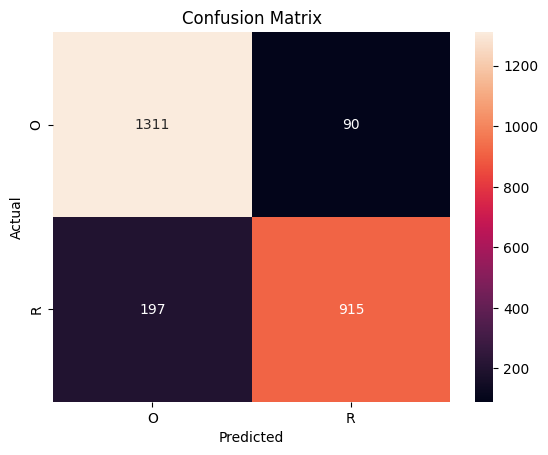

VGG19 Performance
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 396ms/step
              precision    recall  f1-score   support

           O       0.86      0.94      0.90      1401
           R       0.92      0.81      0.86      1112

    accuracy                           0.89      2513
   macro avg       0.89      0.88      0.88      2513
weighted avg       0.89      0.89      0.88      2513



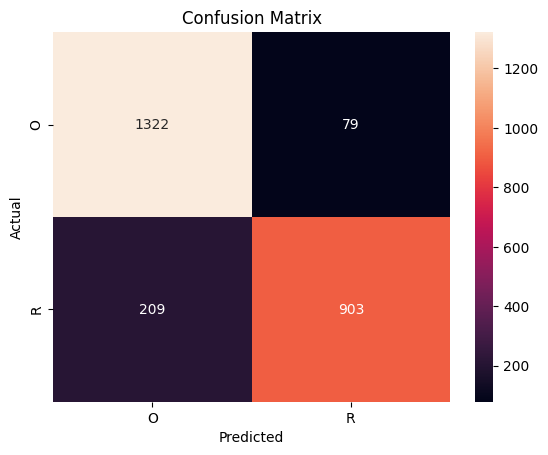

Enhanced CNN Performance
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step
              precision    recall  f1-score   support

           O       0.80      0.95      0.87      1401
           R       0.91      0.71      0.80      1112

    accuracy                           0.84      2513
   macro avg       0.86      0.83      0.83      2513
weighted avg       0.85      0.84      0.84      2513



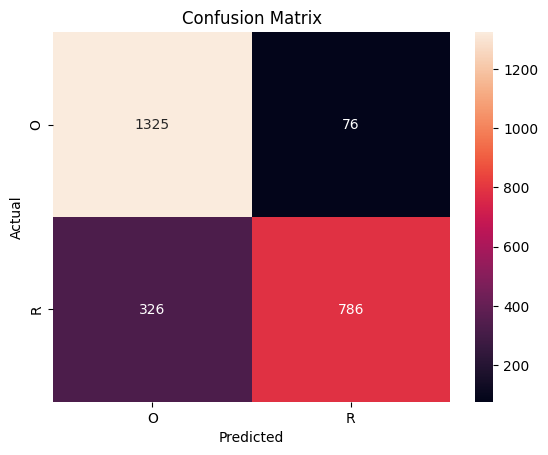

In [20]:
print("Baseline CNN Performance")
evaluate_model(baseline_model, test_data)

print("VGG19 Performance")
evaluate_model(vgg_model, test_data)

print("Enhanced CNN Performance")
evaluate_model(enhanced_model, test_data)

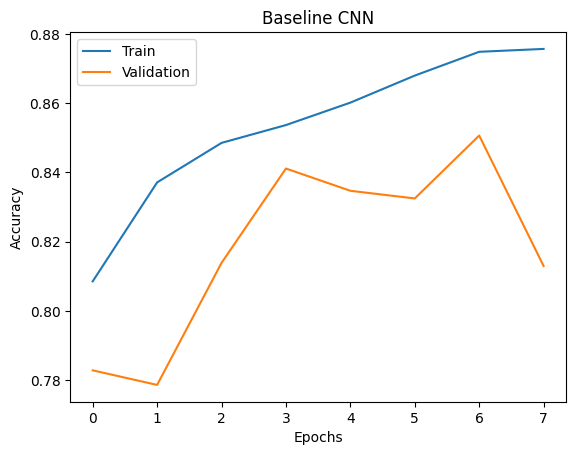

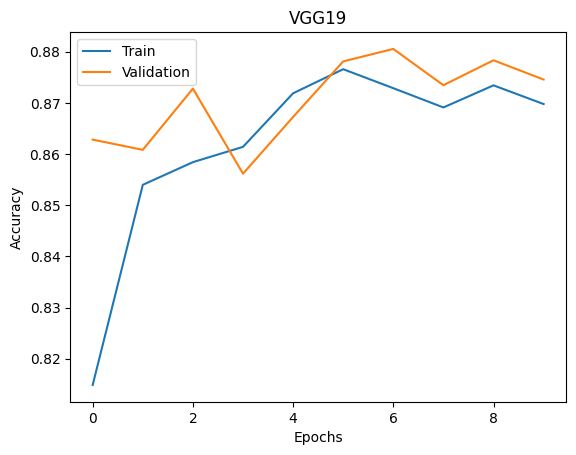

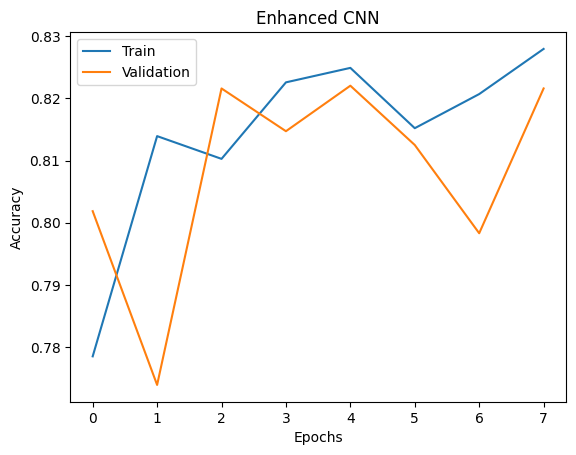

In [21]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

plot_history(history_baseline, "Baseline CNN")
plot_history(history_vgg, "VGG19")
plot_history(history_enhanced, "Enhanced CNN")